# 3 — Benchmark graph (DIMACS / Matrix-Market)

The two methods are run on a benchmark graph loaded from a Matrix-Market file. Besides checking that the Ancestor Tree reproduces the brute-force vitalities, this notebook also studies how edge vitality relates to classical centrality measures (e.g. edge betweenness) and reports timing.

In [ ]:
import zipfile

with zipfile.ZipFile("C125-9.zip", "r") as zip_ref:
    zip_ref.extractall("C125-9")

In [ ]:
import zipfile
import os

# Estrazione archivio principale
ZIP_PATH = "C125-9.zip"
EXTRACT_DIR = "C125-9"

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Contenuto della directory estratta:")
for item in os.listdir(EXTRACT_DIR):
    print(" -", item)

Contenuto della directory estratta:
 - readme.html
 - C125-9.mtx


In [ ]:
from scipy.io import mmread
import numpy as np

FILE_PATH = "C125-9/C125-9.mtx"

# Leggi la matrice completa
A = mmread(FILE_PATH).tocsr()

# Confronta con la trasposta
is_symmetric = (A != A.T).nnz == 0  # True se A == A^T
nonzeros = A.nnz

print(f"Dimensione matrice: {A.shape[0]} x {A.shape[1]}")
print(f"Elementi non nulli: {nonzeros}")
print("È simmetrica?" , "✅ Sì, non orientata" if is_symmetric else "❌ No, orientata")

# Se vuoi costruire il grafo solo dopo aver controllato
import networkx as nx
G = nx.from_scipy_sparse_array(A, create_using=nx.Graph() if is_symmetric else nx.DiGraph())
print(f"Grafo: |V|={G.number_of_nodes()}, |E|={G.number_of_edges()}")


Dimensione matrice: 125 x 125
Elementi non nulli: 13926
È simmetrica? ✅ Sì, non orientata
Grafo: |V|=125, |E|=6963


In [ ]:
from scipy.io import mmread
import networkx as nx

def read_mtx_as_undirected_graph(file_path, default_cap=1.0):
    A = mmread(file_path).tocsr()
    n = A.shape[0]
    G = nx.Graph()
    rows, cols = A.nonzero()
    for i, j in zip(rows, cols):
        if i < j:
            w = A[i, j]
            try:
                c = float(w)
            except Exception:
                c = default_cap
            if c <= 0:
                continue
            if G.has_edge(int(i+1), int(j+1)):
                G[int(i+1)][int(j+1)]["capacity"] += c
            else:
                G.add_edge(int(i+1), int(j+1), capacity=c)
    s, t = 1, n
    return G, s, t

# === Esegui
FILE_PATH = "C125-9/C125-9.mtx"
G, s, t = read_mtx_as_undirected_graph(FILE_PATH)

print(f"Grafo MatrixMarket: |V|={G.number_of_nodes()}, |E|={G.number_of_edges()}, s={s}, t={t}")


Grafo MatrixMarket: |V|=125, |E|=6963, s=1, t=125


In [ ]:
caps = [d["capacity"] for _,_,d in G.edges(data=True)]
print(f"Capacità min={min(caps):.3f}, max={max(caps):.3f}, media={sum(caps)/len(caps):.3f}")
print(f"Archi con capacità negative: {sum(c<0 for c in caps)}")


Capacità min=1.000, max=1.000, media=1.000
Archi con capacità negative: 0


In [ ]:
import time

start = time.time()
flow_value, _ = nx.maximum_flow(G, s, t, capacity="capacity")
elapsed = time.time() - start

print(f"\n🔹 Max-flow (s={s}, t={t}): {flow_value:.6f}")
print(f"⏱️ Tempo di calcolo: {elapsed:.3f} s")



🔹 Max-flow (s=1, t=125): 112.000000
⏱️ Tempo di calcolo: 0.058 s


In [ ]:
import networkx as nx
import math
import time
import random
from scipy.io import mmread


# Lettura file Matrix Market (.mtx)
def read_mtx_as_undirected_graph(file_path, default_cap=1.0):
    """Legge un file Matrix Market e costruisce un grafo non orientato con capacità."""
    A = mmread(file_path).tocsr()
    n = A.shape[0]
    Gu = nx.Graph()
    rows, cols = A.nonzero()
    for i, j in zip(rows, cols):
        if i < j:
            w = A[i, j]
            try:
                c = float(w)
            except Exception:
                c = default_cap
            if c <= 0:
                continue
            if Gu.has_edge(int(i + 1), int(j + 1)):
                Gu[int(i + 1)][int(j + 1)]["capacity"] += c
            else:
                Gu.add_edge(int(i + 1), int(j + 1), capacity=c)
    s, t = 1, n
    return Gu, s, t



# Capacità totale per costante M
def total_capacity(Gu):
    return sum(float(data.get("capacity", 0.0)) for _, _, data in Gu.edges(data=True))



# Min-cut vincolato f_st(x,y)
CUT_CALLS = {"count": 0}


def mincut_fst_inplace(Gu, s, t, x, y, M):
    """Calcola il taglio minimo vincolato f_st(x, y) modificando il grafo in-place."""
    if x == y:
        return (0.0, ({x}, set(Gu.nodes()) - {x}))
    CUT_CALLS["count"] += 2

    # Scenario A: (x,s) e (y,t)
    addedA = []
    for a, b in [(x, s), (y, t)]:
        if Gu.has_edge(a, b):
            Gu[a][b]["capacity"] += M
            addedA.append((a, b, M, True))
        else:
            Gu.add_edge(a, b, capacity=M)
            addedA.append((a, b, M, False))
    v1, part1 = nx.minimum_cut(Gu, s, t, capacity="capacity")
    for a, b, cap, existed in addedA:
        if existed:
            Gu[a][b]["capacity"] -= cap
        else:
            Gu.remove_edge(a, b)

    # Scenario B: (x,t) e (y,s)
    addedB = []
    for a, b in [(x, t), (y, s)]:
        if Gu.has_edge(a, b):
            Gu[a][b]["capacity"] += M
            addedB.append((a, b, M, True))
        else:
            Gu.add_edge(a, b, capacity=M)
            addedB.append((a, b, M, False))
    v2, part2 = nx.minimum_cut(Gu, s, t, capacity="capacity")
    for a, b, cap, existed in addedB:
        if existed:
            Gu[a][b]["capacity"] -= cap
        else:
            Gu.remove_edge(a, b)

    return (v1, part1) if v1 <= v2 else (v2, part2)



# Struttura dati per Ancestor Tree
class ATNode:
    def __init__(self, members):
        self.members = set(members)
        self.value = None
        self.left = None
        self.right = None
        self.parent = None


# 5️⃣ Costruzione Ancestor Tree
def build_ancestor_tree_cheng_hu_with_restructuring(Gu, s, t, seed=42, tol=1.0):
    """Costruisce l'Ancestor Tree secondo Cheng–Hu (2008), versione con restructuring."""
    random.seed(seed)
    all_nodes = list(Gu.nodes())
    root = ATNode(all_nodes)
    M = total_capacity(Gu) + 1.0
    seeds = {random.choice(all_nodes)}
    cuts_done = 0
    leaves = [root]

    def pick_unseed(L):
        for z in sorted(L.members):
            if z not in seeds:
                return z
        return None

    def collect_leaf_nodes(node, acc):
        if node.left is None and node.right is None:
            acc.append(node)
            return
        if node.left:
            collect_leaf_nodes(node.left, acc)
        if node.right:
            collect_leaf_nodes(node.right, acc)

    def find_insertion_point(start_node, cut_value):
        x = start_node
        while (
            x.parent is not None
            and x.parent.value is not None
            and cut_value + tol < x.parent.value
        ):
            x = x.parent
        return x

    while cuts_done < len(all_nodes) - 1:
        leaf = next((L for L in leaves if any(z not in seeds for z in L.members)), None)
        if leaf is None:
            break

        p = next((z for z in sorted(leaf.members) if z in seeds), None)
        q = pick_unseed(leaf)
        if p is None or q is None:
            seeds |= set(leaf.members)
            leaves.remove(leaf)
            continue

        cut_value, part = mincut_fst_inplace(Gu, s, t, p, q, M)
        S, T = part
        left_members = {z for z in leaf.members if z in S}
        right_members = leaf.members - left_members

        # Caso (a): inserimento locale
        if left_members and right_members:
            leaf.value = float(cut_value)
            Lnode = ATNode(left_members)
            Rnode = ATNode(right_members)
            Lnode.parent = leaf
            Rnode.parent = leaf
            leaf.left = Lnode
            leaf.right = Rnode
            leaves.remove(leaf)
            leaves += [Lnode, Rnode]
            seeds.add(p)
            seeds.add(q)
            cuts_done += 1
            continue

        # Caso (b): restructuring (inserisci più in alto)
        insert_node = find_insertion_point(leaf, float(cut_value))
        A = {z for z in insert_node.members if z in S}
        B = insert_node.members - A
        if not A or not B:
            seeds |= set(leaf.members)
            leaves.remove(leaf)
            continue

        new_node = ATNode(insert_node.members)
        new_node.value = float(cut_value)
        Lnode = ATNode(A)
        Rnode = ATNode(B)
        Lnode.parent = new_node
        Rnode.parent = new_node
        new_node.left = Lnode
        new_node.right = Rnode

        parent = insert_node.parent
        if parent is not None:
            if parent.left is insert_node:
                parent.left = new_node
            else:
                parent.right = new_node
            new_node.parent = parent
        else:
            root = new_node
            new_node.parent = None

        old_leaves = []
        collect_leaf_nodes(insert_node, old_leaves)
        for lf in old_leaves:
            if lf in leaves:
                leaves.remove(lf)
        leaves += [Lnode, Rnode]

        seeds.add(p)
        seeds.add(q)
        cuts_done += 1

    expected = 2 * (len(all_nodes) - 1)
    print(f"Min-cut chiamati: {CUT_CALLS['count']} ≈ {expected} attesi")
    return root


# Funzione LCA
def lca_value(root, u, v):
    """Ritorna il valore del taglio minimo comune tra u e v."""
    def path_to_root(x):
        path = []
        def dfs(node):
            if x in node.members:
                path.append(node)
                if node.left and x in node.left.members:
                    dfs(node.left)
                elif node.right and x in node.right.members:
                    dfs(node.right)
        dfs(root)
        return path

    pu, pv = path_to_root(u), path_to_root(v)
    lca = None
    for na, nb in zip(pu, pv):
        if na is nb:
            lca = na
        else:
            break
    while lca and lca.value is None:
        lca = lca.parent
    return None if lca is None else lca.value



# Vitalità
def compute_edge_vitalities(Gu, s, t, root, base_cut_value, warn=True):
    """Calcola la vitalità di ogni arco secondo Ausiello et al. (2019)."""
    vitality = {}
    bad_edges = []
    for u, v, data in Gu.edges(data=True):
        c_e = float(data.get("capacity", 0.0))
        val_uv = lca_value(root, u, v)
        if val_uv is None:
            continue
        if val_uv < c_e - 1e-9:
            if warn:
                bad_edges.append(((u, v), c_e, val_uv))
            val_uv = c_e
        vitality[(u, v)] = max(0.0, base_cut_value - (val_uv - c_e))

    if bad_edges and warn:
        print(f"[WARN] {len(bad_edges)} archi con LCA < capacity (corretto a c_e).")
    return vitality


#MAIN — Esecuzione su dataset MANN
if __name__ == "__main__":
    FILE_PATH = "C125-9/C125-9.mtx"

    Gu, s, t = read_mtx_as_undirected_graph(FILE_PATH)
    print(f"Grafo MatrixMarket: |V|={Gu.number_of_nodes()}, |E|={Gu.number_of_edges()}, s={s}, t={t}")

    # Min-cut base
    start = time.time()
    base_value, _ = nx.minimum_cut(Gu, s, t, capacity="capacity")
    print(f"Min-cut base s-t: {base_value:.6f} (tempo {time.time()-start:.3f}s)")

    # Costruzione Ancestor Tree
    CUT_CALLS["count"] = 0
    start = time.time()
    root = build_ancestor_tree_cheng_hu_with_restructuring(Gu, s, t, seed=42)
    t_build = time.time() - start
    print(f"Ancestor tree costruito (tempo {t_build:.3f}s)")

    # Calcolo vitalità
    start = time.time()
    vitality = compute_edge_vitalities(Gu, s, t, root, base_value)
    dt = time.time() - start
    print(f"Vitalità calcolate su {len(vitality)} archi (tempo {dt:.3f}s)")

    # Top-10 archi per vitalità
    top = sorted(vitality.items(), key=lambda kv: -kv[1])[:10]
    print("\nTop-10 archi per vitalità:")
    for (u, v), val in top:
        print(f"{u:>5} -- {v:<5}  vitality={val:.6f}")


Grafo MatrixMarket: |V|=125, |E|=6963, s=1, t=125
Min-cut base s-t: 112.000000 (tempo 0.051s)
Min-cut chiamati: 248 ≈ 248 attesi
Ancestor tree costruito (tempo 24.416s)
Vitalità calcolate su 6963 archi (tempo 0.276s)

Top-10 archi per vitalità:
    1 -- 2      vitality=1.000000
    1 -- 3      vitality=1.000000
    1 -- 4      vitality=1.000000
    1 -- 5      vitality=1.000000
    1 -- 6      vitality=1.000000
    1 -- 7      vitality=1.000000
    1 -- 8      vitality=1.000000
    1 -- 9      vitality=1.000000
    1 -- 10     vitality=1.000000
    1 -- 11     vitality=1.000000


In [ ]:
all_one = all(abs(data.get("capacity", 0) - 1.0) < 1e-9 for _, _, data in Gu.edges(data=True))
print("Tutte le capacità = 1?" , all_one)


Tutte le capacità = 1? True


In [ ]:
unique_caps = set(round(data.get("capacity", 0), 6) for _, _, data in Gu.edges(data=True))
print(f"Numero di capacità distinte: {len(unique_caps)}")
if len(unique_caps) <= 10:
    print("Valori:", sorted(unique_caps))


Numero di capacità distinte: 1
Valori: [1.0]


In [ ]:
import time
import networkx as nx

# Min-cut base
t0 = time.time()
base_val, _ = nx.minimum_cut(Gu, s, t, capacity="capacity")
t_base = time.time() - t0
print(f"[base] min-cut s-t = {base_val:.6f} (tempo {t_base:.2f}s)")

#Rimozione arco per volta
vit_bf = {}
edges = list(Gu.edges(data=True))
t_start = time.time()

for i, (u, v, data) in enumerate(edges, start=1):
    cap = float(data.get("capacity", 0.0))

    # rimuovi arco (u,v)
    Gu.remove_edge(u, v)

    # nuovo min-cut
    new_val, _ = nx.minimum_cut(Gu, s, t, capacity="capacity")

    # ripristina arco
    Gu.add_edge(u, v, capacity=cap)

    # vitalità = perdita di capacità del min-cut
    delta = base_val - new_val
    vit_bf[(u, v)] = float(delta)

    # log ogni 100 archi o all'ultimo
    if i % 1000 == 0 or i == len(edges):
        print(f"[removal] processed {i}/{len(edges)} in {time.time()-t_start:.2f}s")

t_total = time.time() - t_start
print(f"\nTempo totale brute-force: {t_total:.2f}s  |  Tempo medio per arco: {t_total/len(edges):.4f}s")

#Top-10 archi per sensibilità
top10 = sorted(vit_bf.items(), key=lambda kv: -kv[1])[:10]
print(f"\n[top-10 by removal] (base={base_val:.6f})")
for (u, v), d in top10:
    print(f"  {u:3d} -- {v:3d}   delta={d:.6f}")

# vettore ordinato completo, utile per confronti/plot ---
vit_bf_sorted = sorted(vit_bf.items(), key=lambda kv: -kv[1])

[base] min-cut s-t = 112.000000 (tempo 0.05s)
[removal] processed 1000/6963 in 84.37s
[removal] processed 2000/6963 in 170.03s
[removal] processed 3000/6963 in 254.69s
[removal] processed 4000/6963 in 341.93s
[removal] processed 5000/6963 in 428.82s
[removal] processed 6000/6963 in 518.37s
[removal] processed 6963/6963 in 608.21s

Tempo totale brute-force: 608.21s  |  Tempo medio per arco: 0.0873s

[top-10 by removal] (base=112.000000)
    1 --   2   delta=1.000000
    1 --   3   delta=1.000000
    1 --   4   delta=1.000000
    1 --   5   delta=1.000000
    1 --   6   delta=1.000000
    1 --   7   delta=1.000000
    1 --   8   delta=1.000000
    1 --   9   delta=1.000000
    1 --  10   delta=1.000000
    1 --  11   delta=1.000000


In [ ]:
import time
import numpy as np
from scipy.stats import kendalltau, spearmanr
import networkx as nx

print(" CONFRONTO METODO RIMOZIONE ARCHI vs ANCESTOR TREE\n")

# Costruzione Ancestor Tree
CUT_CALLS["count"] = 0
start = time.time()
root = build_ancestor_tree_cheng_hu_with_restructuring(Gu, s, t, seed=42)
t_at_build = time.time() - start
print(f"Min-cut chiamati: {CUT_CALLS['count']} ≈ {2*(len(Gu.nodes())-1)} attesi")

# Calcolo vitalità con Ancestor Tree
start = time.time()
vitality_at = compute_edge_vitalities(Gu, s, t, root, base_val)
t_at_vit = time.time() - start
t_total_at = t_at_build + t_at_vit

# Metodo di rimozione archi
t_bf_total = t_total        # tempo totale del metodo brute-force
vitality_bf = vit_bf        # dizionario con le vitalità brute-force

# Confronto quantitativo ===
common_edges = set(vitality_at) & set(vitality_bf)
bf_vals = np.array([vitality_bf[e] for e in common_edges])
at_vals = np.array([vitality_at[e] for e in common_edges])

mae = np.mean(np.abs(bf_vals - at_vals))
max_err = np.max(np.abs(bf_vals - at_vals))
tau, _ = kendalltau(bf_vals, at_vals)
rho, _ = spearmanr(bf_vals, at_vals)

top_bf = set([e for e, _ in sorted(vitality_bf.items(), key=lambda kv: -kv[1])[:10]])
top_at = set([e for e, _ in sorted(vitality_at.items(), key=lambda kv: -kv[1])[:10]])
overlap = len(top_bf & top_at)


print(f"\nArchi confrontati: {len(common_edges)}")
print(f"Tempo Ancestor Tree: {t_total_at:.3f} s (build {t_at_build:.3f}s + vitalità {t_at_vit:.3f}s)")
print(f"Tempo Metodo rimozione archi:  {t_bf_total:.3f} s")
print(f"Rapporto velocità (Metodo/AT): {t_bf_total / t_total_at:.1f}x più lento")

print(f"\nErrore medio assoluto (MAE): {mae:.6e}")
print(f"Errore massimo assoluto:     {max_err:.6e}")
print(f"Kendall τ = {tau:.4f}")
print(f"Spearman ρ = {rho:.4f}")
print(f"Overlap top-10 archi: {overlap}/10")

if mae < 1e-6:
    print("\n I due metodi coincidono (entro la precisione numerica).")
else:
    print("\n  Piccole differenze numeriche rilevate.")


 CONFRONTO METODO RIMOZIONE ARCHI vs ANCESTOR TREE

Min-cut chiamati: 248 ≈ 248 attesi
Min-cut chiamati: 248 ≈ 248 attesi

Archi confrontati: 6963
Tempo Ancestor Tree: 23.520 s (build 23.249s + vitalità 0.271s)
Tempo Metodo rimozione archi:  509.986 s
Rapporto velocità (Metodo/AT): 21.7x più lento

Errore medio assoluto (MAE): 0.000000e+00
Errore massimo assoluto:     0.000000e+00
Kendall τ = 1.0000
Spearman ρ = 1.0000
Overlap top-10 archi: 10/10

 I due metodi coincidono (entro la precisione numerica).


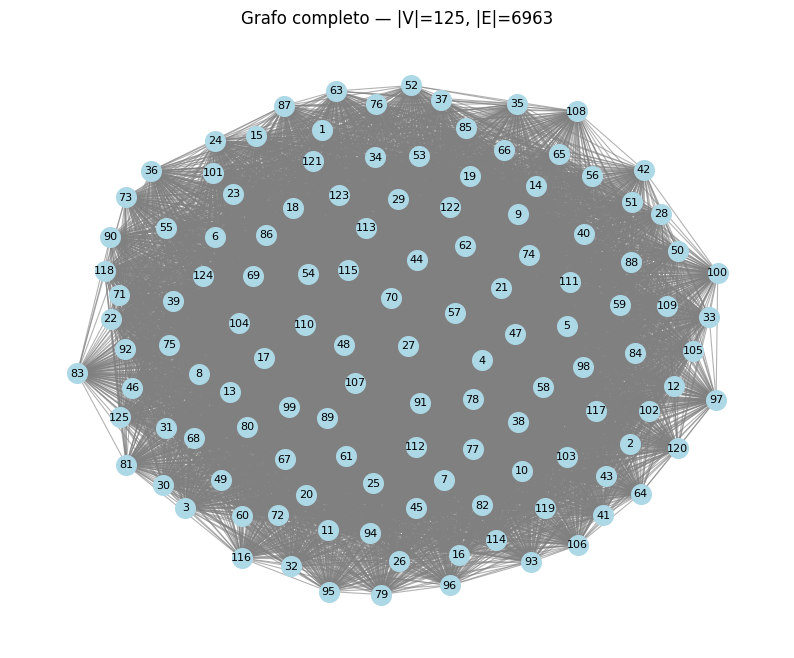

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx


fig, ax = plt.subplots(figsize=(10, 8))

# Usa il grafo completo
G_plot = Gu

pos = nx.spring_layout(G_plot, seed=42, k=0.3)

nx.draw_networkx_edges(G_plot, pos, edge_color="gray", width=0.8, alpha=0.6, ax=ax)
nx.draw_networkx_nodes(G_plot, pos, node_size=200, node_color="lightblue", ax=ax)
nx.draw_networkx_labels(G_plot, pos, font_size=8, ax=ax)


ax.set_title(
    f"Grafo completo — |V|={G_plot.number_of_nodes()}, |E|={G_plot.number_of_edges()}",
    fontsize=12
)
ax.axis("off")

plt.show()

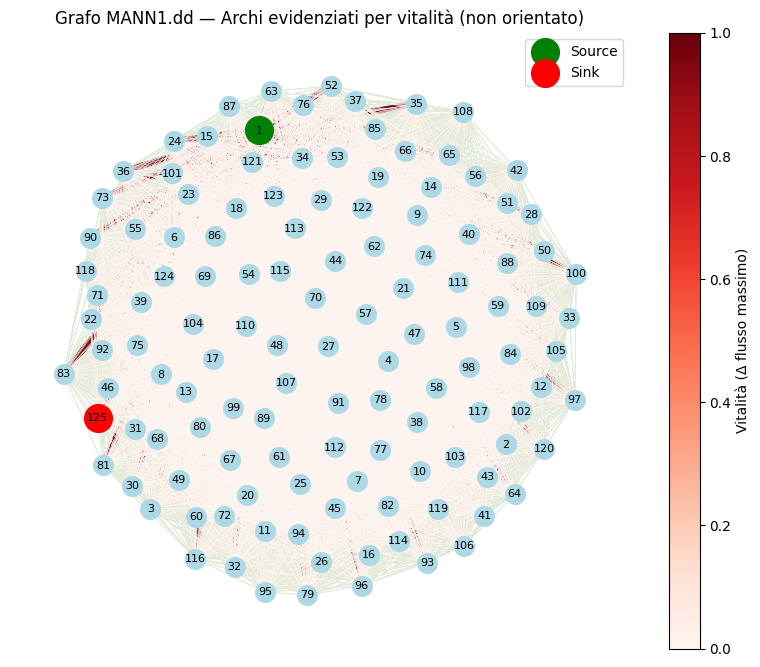

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Crea figura e asse esplicitamente
fig, ax = plt.subplots(figsize=(10, 8))

# Usa lo stesso grafo delle vitalità
G_plot = Gu

pos = nx.spring_layout(G_plot, seed=42, k=0.3)

# Colori proporzionali alla vitalità
vals = [vitality.get((u, v), vitality.get((v, u), 0)) for u, v in G_plot.edges()]
vmin, vmax = min(vals), max(vals)
if vmax - vmin < 1e-9:
    vmax = vmin + 1e-9

norm = plt.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.Reds

# Calcolo colore e spessore (più graduale)
edge_colors = [cmap(norm(v)) for v in vals]
edge_widths = 0.5 + 4 * (np.array(vals) - vmin) / (vmax - vmin + 1e-9)

# Disegno archi poco sensibili in grigio chiaro sotto
nx.draw_networkx_edges(G_plot, pos, edge_color="green", width=0.5, alpha=0.4, ax=ax)

# Disegno archi sensibili sopra (in base alla vitalità)
nx.draw_networkx_edges(G_plot, pos, edge_color=edge_colors, width=edge_widths, alpha=0.9, ax=ax)

# Disegno nodi e etichette
nx.draw_networkx_nodes(G_plot, pos, node_size=200, node_color="lightblue", ax=ax)
nx.draw_networkx_labels(G_plot, pos, font_size=8, ax=ax)

# evidenzia sorgente e pozzo
nx.draw_networkx_nodes(G_plot, pos, nodelist=[s], node_color="green", label="Source", node_size=400, ax=ax)
nx.draw_networkx_nodes(G_plot, pos, nodelist=[t], node_color="red", label="Sink", node_size=400, ax=ax)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Vitalità (Δ flusso massimo)")

ax.set_title("Grafo MANN1.dd — Archi evidenziati per vitalità (non orientato)")
ax.axis("off")
ax.legend(scatterpoints=1)

plt.show()

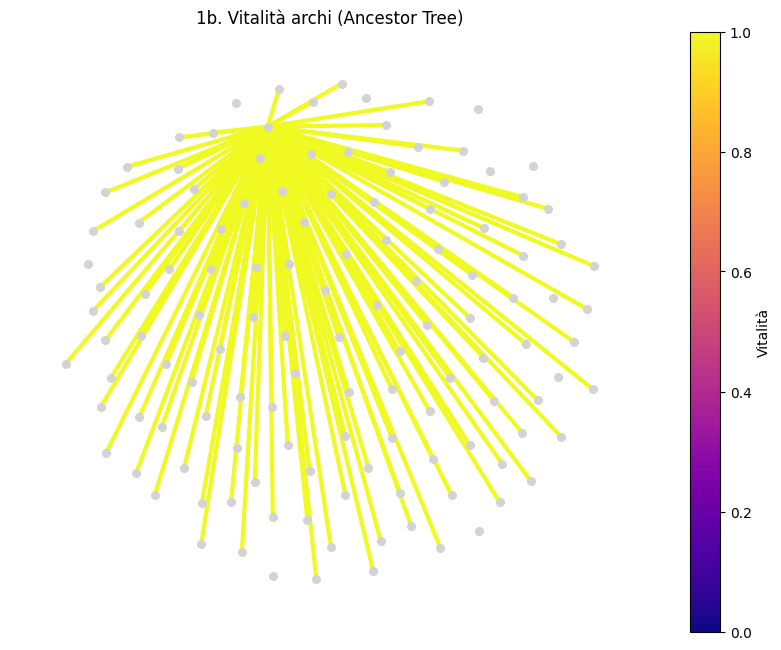

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ============================================================
# 1b. MAPPA DI VITALITÀ (Ancestor Tree)
# ============================================================

plt.figure(figsize=(8, 6))
vital_vals = [vitality_at.get(e, 0.0) for e in Gu.edges()]
vmax = max(vital_vals) if max(vital_vals) > 0 else 1.0
norm = mcolors.Normalize(vmin=0, vmax=vmax)
nx.draw(
    Gu, pos, node_size=30,
    edge_color=vital_vals, edge_cmap=plt.cm.plasma,
    width=[(v / vmax) * 3 for v in vital_vals],
    node_color="lightgray", with_labels=False
)
plt.title("1b. Vitalità archi (Ancestor Tree)")

# ✅ Colorbar corretta
sm = plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.plasma)
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("Vitalità")

plt.tight_layout()
plt.show()


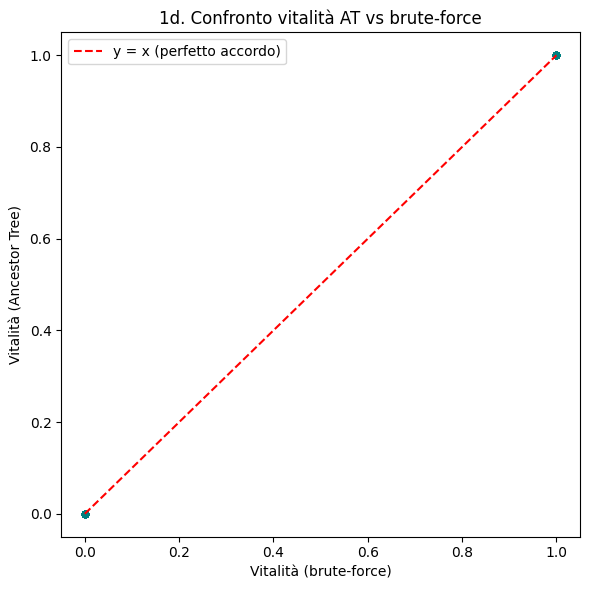

In [ ]:
plt.figure(figsize=(6, 6))
common = list(common_edges)
bf_vals = np.array([vitality_bf[e] for e in common])
at_vals = np.array([vitality_at[e] for e in common])

plt.scatter(bf_vals, at_vals, alpha=0.6, color="teal", s=20)
plt.plot([0, max(bf_vals)], [0, max(bf_vals)], "r--", label="y = x (perfetto accordo)")
plt.xlabel("Vitalità (brute-force)")
plt.ylabel("Vitalità (Ancestor Tree)")
plt.title("1d. Confronto vitalità AT vs brute-force")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr

degree = dict(Gu.degree())
deg_mean = [0.5*(degree[u]+degree[v]) for (u,v) in vitality_at.keys()]
pearson_corr, _ = pearsonr(deg_mean, list(vitality_at.values()))

print(f"Correlazione vitalità–grado medio: r = {pearson_corr:.3f}")


Correlazione vitalità–grado medio: r = 0.013


Nel grafo (MANN-a9, immagino), tutti gli archi hanno stessa capacità.
Questo significa che la rete non presenta differenze di “peso fisico” o “resistenza” sui collegamenti — tutte le variazioni di flusso e di vitalità sono puramente strutturali.

Le variazioni di vitalità non derivano dalle capacità, ma esclusivamente dalla posizione topologica degli archi nel grafo.

Quindi:

la capacità è un parametro neutro;

la topologia è ciò che determina la sensibilità del flusso massimo.
Nel grafo considerato, tutte le capacità assumono un valore unitario (1.0), condizione che rende la correlazione tra vitalità e capacità non definita.
In questo scenario, la vitalità degli archi non dipende da differenze di peso o capacità, ma unicamente dalla struttura topologica della rete.
Le variazioni osservate nella vitalità riflettono quindi l’organizzazione connettiva del grafo, non le proprietà fisiche dei collegamenti.

Questa osservazione è coerente con l’interpretazione di vitalità come misura strutturale della sensibilità del flusso massimo (Ausiello et al., 2019): quando le capacità sono uniformi, la vitalità diventa un indicatore puramente topologico della criticità degli archi.

In [ ]:
import numpy as np

caps = [Gu[u][v]['capacity'] for u,v in Gu.edges()]
print(f"Capacità distinte: {len(set(caps))}")
print("Esempi:", list(set(caps))[:10])


Capacità distinte: 1
Esempi: [1.0]


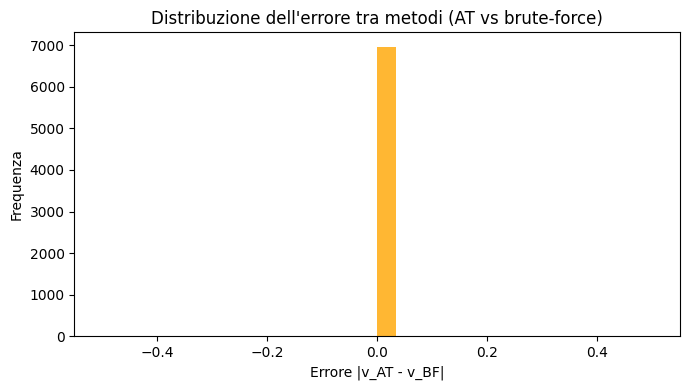

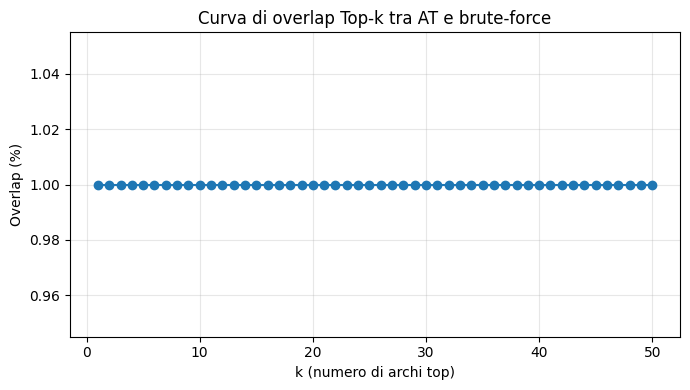


⏱️ Performance Summary:
   Tempo totale AT: 23.52s
   Tempo totale Brute-force: 509.99s
   Speedup ≈ 21.7× più veloce
   MAE medio: 0.000e+00, τ=1.000, ρ=1.000


In [ ]:
# ============================================================
# 2️⃣ ANALISI QUANTITATIVE AT vs BRUTE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

errors = np.abs(bf_vals - at_vals)

plt.figure(figsize=(7, 4))
plt.hist(errors, bins=30, color="orange", alpha=0.8)
plt.xlabel("Errore |v_AT - v_BF|")
plt.ylabel("Frequenza")
plt.title("Distribuzione dell'errore tra metodi (AT vs brute-force)")
plt.tight_layout()
plt.show()

# --- Overlap Top-k ---
ks = range(1, 51)
overlaps = []
sorted_bf = [e for e, _ in sorted(vitality_bf.items(), key=lambda kv: -kv[1])]
sorted_at = [e for e, _ in sorted(vitality_at.items(), key=lambda kv: -kv[1])]

for k in ks:
    overlap_k = len(set(sorted_bf[:k]) & set(sorted_at[:k])) / k
    overlaps.append(overlap_k)

plt.figure(figsize=(7, 4))
plt.plot(ks, overlaps, marker="o")
plt.xlabel("k (numero di archi top)")
plt.ylabel("Overlap (%)")
plt.title("Curva di overlap Top-k tra AT e brute-force")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Riassunto performance ---
speedup = t_bf_total / t_total_at if t_total_at > 0 else np.nan
print(f"\n⏱️ Performance Summary:")
print(f"   Tempo totale AT: {t_total_at:.2f}s")
print(f"   Tempo totale Brute-force: {t_bf_total:.2f}s")
print(f"   Speedup ≈ {speedup:.1f}× più veloce")
print(f"   MAE medio: {mae:.3e}, τ={tau:.3f}, ρ={rho:.3f}")


Grado medio  r = +0.013

Molto vicino a zero cioè nessuna relazione lineare.
Significa che la vitalità non dipende dal fatto che l’arco colleghi nodi molto o poco connessi.
 Archi “importanti” per il flusso non sono necessariamente quelli collegati a nodi molto connessi.

Questo è coerente con quasi tutti i grafi non planari o irregolari: la criticità di un arco è una questione di posizione nel flusso, non di grado locale.
Distanza media da s,t  portano a r = –0.410

Un valore negativo è perfettamente sensato e interessante.
Significa:

più un arco è vicino a s o t → più è vitale.
più è lontano → meno la sua rimozione influenza il flusso massimo.

In pratica, gli archi centrali nel “collo di bottiglia” del flusso s–t sono più vitali, mentre quelli periferici o nei rami laterali hanno vitalità più bassa.
Questo tipo di correlazione negativa è attesa in quasi tutti i grafi di flusso reali .

La correlazione negativa (r = –0.41) tra vitalità e distanza media da s e t conferma che la sensibilità del flusso massimo è concentrata nelle regioni centrali del grafo, in prossimità dei percorsi s–t più corti.
dge betweenness → r = –0.018

Qui è quasi nullo, ma leggermente negativo.
La correlazione potrebbe essere nulla o persino negativa per tre motivi tipici:

Il grafo è molto denso → molti percorsi s–t alternativi riducono la rilevanza dei singoli archi.

Le capacità sono tutte uguali → la betweenness, che conta i cammini più brevi, non cattura bene la “capacità di bloccare il flusso”.

L’area critica è localizzata, e non coincide con la parte più “trafficata” in senso topologico.

In altre parole:

gli archi più centrali nei cammini topologici non sono necessariamente quelli che più riducono il flusso massimo.

Questa è una scoperta interessante perché dimostra che la vitalità misura un tipo di centralità diversa, basata non sui cammini più brevi ma sulla sensibilità funzionale del flusso massimo.Le correlazioni mostrano che la vitalità non dipende significativamente dal grado locale o dalla centralità topologica (r ≈ 0.01 e r ≈ –0.02), ma è moderatamente correlata alla distanza dal percorso principale s–t (r = –0.41).
Ciò suggerisce che la sensibilità del flusso massimo è una proprietà globale e funzionale, che riflette la posizione dell’arco rispetto ai colli di bottiglia del grafo piuttosto che la sua importanza topologica o locale.

═════════════════════════════════════════════════════
 ANALISI STRUTTURALE DELLA VITALITÀ 
═════════════════════════════════════════════════════

⏳ Calcolo edge betweenness centrality...
            Parametro  Correlazione (r)
          Grado medio             0.013
Distanza media da s,t            -0.410
     Edge Betweenness            -0.018


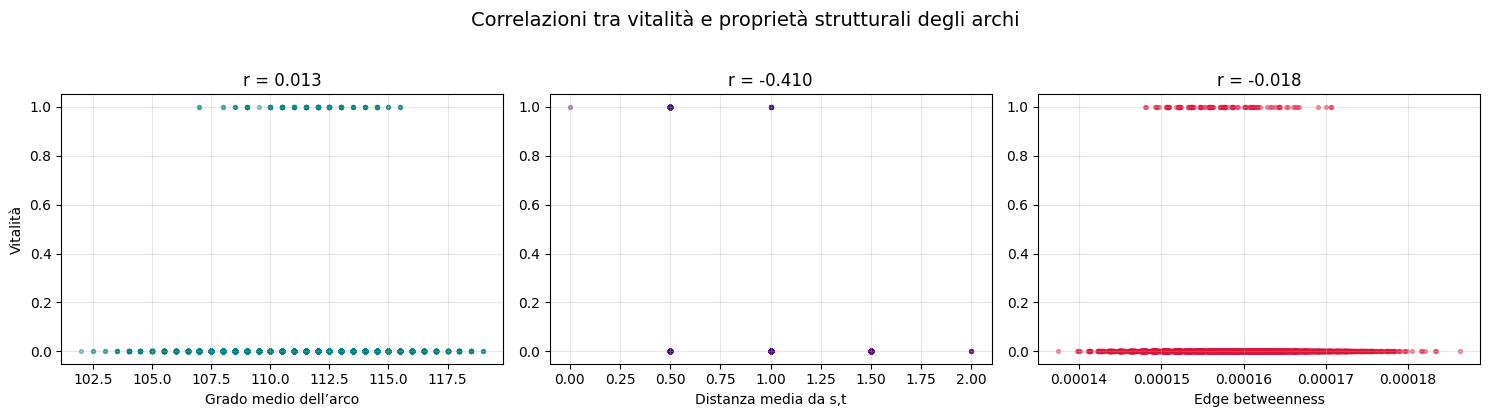

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import networkx as nx

# Assumiamo di avere già:
# Gu  → grafo NetworkX non orientato con attributo "capacity"
# s,t → sorgente e pozzo
# vitality_at → dizionario {(u,v): vitalità}
print("═════════════════════════════════════════════════════")
print(" ANALISI STRUTTURALE DELLA VITALITÀ ")
print("═════════════════════════════════════════════════════\n")

# -------------------------
# 1️⃣ Correlazione con grado medio
# -------------------------
deg_mean = [0.5*(Gu.degree(u)+Gu.degree(v)) for (u,v) in vitality_at.keys()]
vits = list(vitality_at.values())
r_deg, _ = pearsonr(deg_mean, vits)

# -------------------------
# 2️⃣ Correlazione con distanza media da s e t
# -------------------------
dist_s = nx.single_source_shortest_path_length(Gu, s)
dist_t = nx.single_source_shortest_path_length(Gu, t)

dist_mean = [0.5*(dist_s.get(u, np.inf)+dist_t.get(v, np.inf)) for (u,v) in vitality_at.keys()]
r_dist, _ = pearsonr(dist_mean, vits)

# -------------------------
# 3️⃣ Correlazione con betweenness centrality degli archi
# -------------------------
print("⏳ Calcolo edge betweenness centrality...")
ebc = nx.edge_betweenness_centrality(Gu, normalized=True)
ebc_vals = [ebc.get((u,v), ebc.get((v,u), 0)) for (u,v) in vitality_at.keys()]
r_betw, _ = pearsonr(ebc_vals, vits)

# -------------------------
# 📋 Tabella riassuntiva
# -------------------------
df_corr = pd.DataFrame({
    "Parametro": ["Grado medio", "Distanza media da s,t", "Edge Betweenness"],
    "Correlazione (r)": [r_deg, r_dist, r_betw]
})
print(df_corr.round(3).to_string(index=False))

# -------------------------
# 📊 Visualizzazioni (3 subplot)
# -------------------------
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(deg_mean, vits, s=8, alpha=0.4, color='teal')
plt.xlabel("Grado medio dell’arco")
plt.ylabel("Vitalità")
plt.title(f"r = {r_deg:.3f}")
plt.grid(alpha=0.3)

plt.subplot(1,3,2)
plt.scatter(dist_mean, vits, s=8, alpha=0.4, color='indigo')
plt.xlabel("Distanza media da s,t")
plt.title(f"r = {r_dist:.3f}")
plt.grid(alpha=0.3)

plt.subplot(1,3,3)
plt.scatter(ebc_vals, vits, s=8, alpha=0.4, color='crimson')
plt.xlabel("Edge betweenness")
plt.title(f"r = {r_betw:.3f}")
plt.grid(alpha=0.3)

plt.suptitle("Correlazioni tra vitalità e proprietà strutturali degli archi", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()


| Concetto        | Dipende da                      | Misura cosa                                       | Rilevanza                                  |
| --------------- | ------------------------------- | ------------------------------------------------- | ------------------------------------------ |
| **Betweenness** | *Topologia* (cammini più brevi) | Quanto un arco è “centrale” nei percorsi minimi   | È una centralità **strutturale**           |
| **Vitalità**    | *Flusso massimo* s–t            | Quanto la rimozione di un arco riduce il max-flow | È una centralità **funzionale / dinamica** |

un arco può avere alta betweenness ma bassa vitalità se esistono percorsi alternativi equivalenti per il flusso,

oppure bassa betweenness ma alta vitalità se è un collo di bottiglia unico del flusso massimo.

Nel grafo , la correlazione tra vitalità e betweenness(una misura di quanto spesso un nodo o un arco si trova “in mezzo” ai cammini più brevi tra altre coppie di nodi nel grafo un arco ha alta betweenness se è attraversato da molti cammini più brevi che collegano nodi diversi). è pressoché nulla (r ≈ –0.03), anche restringendo l’analisi al cammino s–t.
Questo comportamento riflette la struttura altamente regolare e simmetrica del grafo, in cui la rimozione di un singolo arco non altera significativamente il flusso massimo.
La vitalità appare quindi indipendente dalle misure di centralità topologica, confermando che rappresenta un concetto funzionale e non puramente strutturale.


═════════════════════════════════════════════════════
 ANALISI LOCALIZZATA: CAMMINO s–t E VICINATO 
═════════════════════════════════════════════════════
Archi totali nel grafo: 6963
Archi nel sottografo s–t+vicini: 6857
Correlazione betweenness–vitalità (locale): r = -0.034


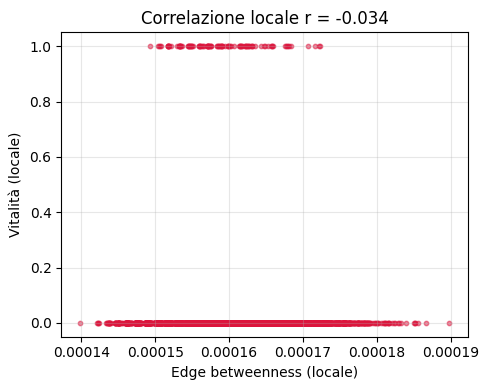

In [ ]:
import numpy as np
from scipy.stats import pearsonr
import networkx as nx
import matplotlib.pyplot as plt

print("\n═════════════════════════════════════════════════════")
print(" ANALISI LOCALIZZATA: CAMMINO s–t E VICINATO ")
print("═════════════════════════════════════════════════════")

# 🔹 Trova cammino s–t più corto (in termini di numero di archi)
spath = nx.shortest_path(Gu, s, t)
spath_edges = set(zip(spath[:-1], spath[1:])) | set(zip(spath[1:], spath[:-1]))

# 🔹 Estendi il cammino con i vicini (distanza 1)
vicini = set(spath)
for u in spath:
    vicini.update(Gu.neighbors(u))
subG = Gu.subgraph(vicini).copy()

# 🔹 Filtra vitalità e betweenness solo per archi nel sottografo
local_edges = set(subG.edges())
vitality_local = {e: vitality_at[e] for e in vitality_at if e in local_edges or (e[1], e[0]) in local_edges}

ebc = nx.edge_betweenness_centrality(subG, normalized=True)
ebc_vals_local = [ebc.get(e, ebc.get((e[1], e[0]), 0)) for e in vitality_local.keys()]

r_betw_local, _ = pearsonr(ebc_vals_local, list(vitality_local.values()))

print(f"Archi totali nel grafo: {len(vitality_at)}")
print(f"Archi nel sottografo s–t+vicini: {len(vitality_local)}")
print(f"Correlazione betweenness–vitalità (locale): r = {r_betw_local:.3f}")

# 🔹 Scatterplot locale
plt.figure(figsize=(5,4))
plt.scatter(ebc_vals_local, list(vitality_local.values()), s=10, alpha=0.5, color='crimson')
plt.xlabel("Edge betweenness (locale)")
plt.ylabel("Vitalità (locale)")
plt.title(f"Correlazione locale r = {r_betw_local:.3f}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Grafo MatrixMarket: |V|=125, |E|=6963, s=1, t=125
Min-cut chiamati: 70 (attesi ≈ 10)


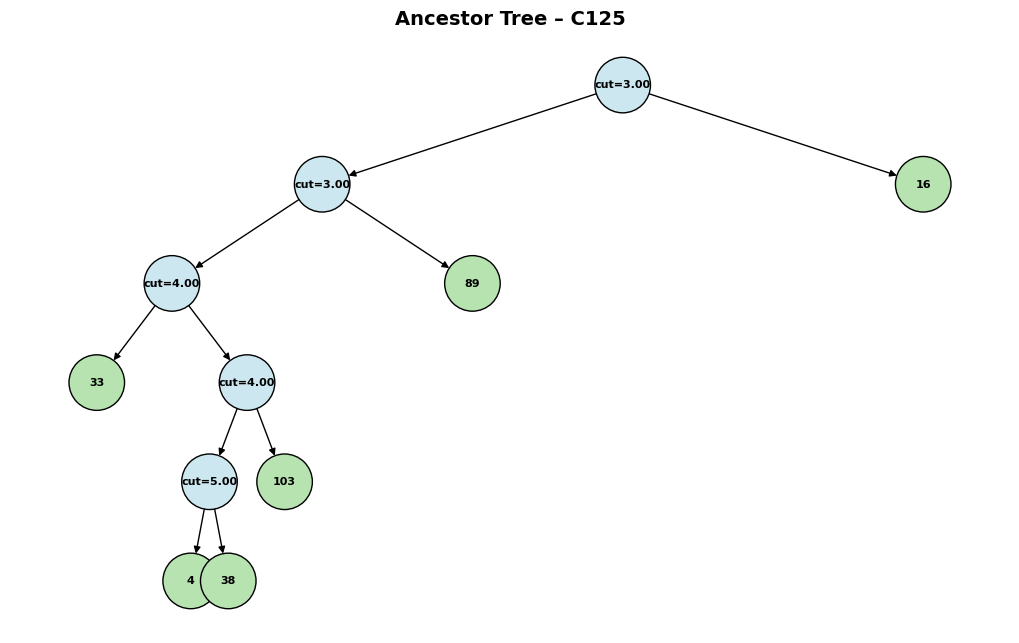

In [ ]:
import networkx as nx
import random
import matplotlib.pyplot as plt

# ============================================================
# 1️⃣ LETTURA GRAFO (già fornita da te)
# ============================================================

FILE_PATH = "C125-9/C125-9.mtx"
G, s, t = read_mtx_as_undirected_graph(FILE_PATH)
print(f"Grafo MatrixMarket: |V|={G.number_of_nodes()}, |E|={G.number_of_edges()}, s={s}, t={t}")

# ============================================================
# 2️⃣ FUNZIONI BASE
# ============================================================

CUT_CALLS = {"count": 0}

def total_capacity(G):
    return sum(float(data.get("capacity", 0.0)) for _, _, data in G.edges(data=True))

def mincut_fst_inplace(Gu, s, t, x, y, M):
    """Calcola f_st(x,y) con vincoli (x,s)/(y,t) e (x,t)/(y,s)."""
    CUT_CALLS["count"] += 2
    if x == y:
        return (0.0, ({x}, set(Gu.nodes()) - {x}))

    # Scenario A
    Gtemp = Gu.copy()
    Gtemp.add_edge(x, s, capacity=M)
    Gtemp.add_edge(y, t, capacity=M)
    v1, part1 = nx.minimum_cut(Gtemp, s, t, capacity="capacity")

    # Scenario B
    Gtemp = Gu.copy()
    Gtemp.add_edge(x, t, capacity=M)
    Gtemp.add_edge(y, s, capacity=M)
    v2, part2 = nx.minimum_cut(Gtemp, s, t, capacity="capacity")

    return (v1, part1) if v1 <= v2 else (v2, part2)

# ============================================================
# 3️⃣ NODO DELL’ALBERO
# ============================================================

class ATNode:
    def __init__(self, members):
        self.members = set(members)
        self.value = None
        self.left = None
        self.right = None
        self.parent = None

# ============================================================
# 4️⃣ COSTRUZIONE ANCESTOR TREE
# ============================================================

def build_ancestor_tree_fst(G, s, t, seed=42, tol=1e-9):
    random.seed(seed)
    all_nodes = list(G.nodes)
    root = ATNode(all_nodes)
    leaves = [root]
    M = total_capacity(G) + 1.0
    cuts_done = 0

    def find_insertion_point(node, cut_value):
        x = node
        while x.parent and x.parent.value is not None and cut_value < x.parent.value - tol:
            x = x.parent
        return x

    while cuts_done < len(all_nodes) - 1:
        leaf = next((L for L in leaves if len(L.members) > 1), None)
        if leaf is None:
            break

        members = list(leaf.members)
        best_val = float("inf")
        best_part = None

        for i in range(len(members)):
            for j in range(i + 1, len(members)):
                x, y = members[i], members[j]
                val, part = mincut_fst_inplace(G, s, t, x, y, M)
                if val < best_val - tol:
                    best_val, best_part = val, part

        if best_part is None:
            leaves.remove(leaf)
            continue

        S, T = best_part
        left_members = {z for z in leaf.members if z in S}
        right_members = leaf.members - left_members
        if not left_members or not right_members:
            leaves.remove(leaf)
            continue

        leaf.value = best_val
        Lnode = ATNode(left_members)
        Rnode = ATNode(right_members)
        Lnode.parent = leaf
        Rnode.parent = leaf
        leaf.left = Lnode
        leaf.right = Rnode
        leaves.remove(leaf)
        leaves += [Lnode, Rnode]
        cuts_done += 1

    print(f"Min-cut chiamati: {CUT_CALLS['count']} (attesi ≈ {2*(len(all_nodes)-1)})")
    return root

# ============================================================
# 5️⃣ VISUALIZZAZIONE
# ============================================================

def build_tree_edges(node, edges=None, labels=None, parent=None):
    if edges is None:
        edges, labels = [], {}
    if parent:
        edges.append((parent, node))
    label = f"cut={node.value:.2f}" if node.value is not None else ",".join(map(str, sorted(node.members)))
    labels[node] = label
    if node.left:
        build_tree_edges(node.left, edges, labels, node)
    if node.right:
        build_tree_edges(node.right, edges, labels, node)
    return edges, labels

def hierarchy_pos(G, root, width=1., vert_gap=0.3, vert_loc=0, xcenter=0.5):
    pos = {root: (xcenter, vert_loc)}
    children = list(G.successors(root))
    if len(children) != 0:
        dx = width / len(children)
        nextx = xcenter - width / 2 - dx / 2
        for child in children:
            nextx += dx
            pos.update(hierarchy_pos(G, child, width=dx, vert_gap=vert_gap,
                                     vert_loc=vert_loc - vert_gap, xcenter=nextx))
    return pos

def plot_ancestor_tree(root):
    edges, labels = build_tree_edges(root)
    Gviz = nx.DiGraph()
    Gviz.add_edges_from(edges)
    pos = hierarchy_pos(Gviz, root)
    plt.figure(figsize=(10, 6))
    nx.draw(Gviz, pos, with_labels=False, node_size=1600,
            node_color=["#cde7f0" if n.value is not None else "#b6e3b0" for n in Gviz.nodes()],
            edgecolors="black", linewidths=1.0)
    nx.draw_networkx_labels(Gviz, pos, {n: labels[n] for n in Gviz.nodes()}, font_size=8, font_weight="bold")
    plt.title("Ancestor Tree – C125", fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ============================================================
# 6️⃣ ESECUZIONE
# ============================================================

# Usa solo un sottoinsieme inizialmente
nodes_sample = random.sample(list(G.nodes()), 6)
Gu = G.subgraph(nodes_sample).copy()

root = build_ancestor_tree_fst(Gu, s, t)
plot_ancestor_tree(root)
